In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from scipy import stats

In [2]:
df = pd.read_csv('/content/sample_data/smart_grid_dataset.csv')

In [3]:
df

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)
0,2024-01-01 00:00:00,232.483571,5.124673,1.191402,0.399029,0.907766,46.614845,26.399566,0.000000,1.055937,0,0,17.842767,64.523353,0.416156,1.233158
1,2024-01-01 00:15:00,229.308678,22.213519,5.093753,1.248030,0.831813,6.907170,18.555011,0.000000,-3.910902,1,0,18.753698,49.671940,0.492334,5.247824
2,2024-01-01 00:30:00,233.238443,46.132217,10.759806,2.790464,0.999005,15.477640,12.905025,0.000000,-0.197551,0,0,16.719325,48.472769,0.427785,10.580278
3,2024-01-01 00:45:00,237.615149,47.648972,11.322118,1.956965,0.896462,35.746398,28.937129,0.000000,2.671921,0,0,15.364564,75.766776,0.487953,11.225946
4,2024-01-01 01:00:00,228.829233,7.410166,1.695663,0.624718,0.870681,27.555038,14.184648,0.000000,3.826937,0,0,38.760333,61.384213,0.290078,1.696639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-06-04 18:45:00,230.283995,34.885717,8.033622,1.412623,0.958675,3.846010,3.773607,0.414005,2.032808,0,0,17.569583,65.013656,0.445045,7.866108
49996,2025-06-04 19:00:00,229.875386,7.380088,1.696501,0.308268,0.907014,16.522504,10.832262,0.000000,-3.274382,0,0,31.907835,25.049143,0.342882,1.753542
49997,2025-06-04 19:15:00,232.500424,43.166952,10.036335,1.631748,0.913899,37.235774,12.475871,0.000000,1.810338,1,0,12.606985,62.469951,0.215314,9.947611
49998,2025-06-04 19:30:00,231.326077,46.254150,10.699791,1.712672,0.948393,22.098785,1.512796,0.000000,1.500918,0,0,26.773676,58.100487,0.147162,10.886454


In [4]:
df.shape

(50000, 16)

In [5]:
df.head()

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)
0,2024-01-01 00:00:00,232.483571,5.124673,1.191402,0.399029,0.907766,46.614845,26.399566,0.0,1.055937,0,0,17.842767,64.523353,0.416156,1.233158
1,2024-01-01 00:15:00,229.308678,22.213519,5.093753,1.248030,0.831813,6.907170,18.555011,0.0,-3.910902,1,0,18.753698,49.671940,0.492334,5.247824
2,2024-01-01 00:30:00,233.238443,46.132217,10.759806,2.790464,0.999005,15.477640,12.905025,0.0,-0.197551,0,0,16.719325,48.472769,0.427785,10.580278
3,2024-01-01 00:45:00,237.615149,47.648972,11.322118,1.956965,0.896462,35.746398,28.937129,0.0,2.671921,0,0,15.364564,75.766776,0.487953,11.225946
4,2024-01-01 01:00:00,228.829233,7.410166,1.695663,0.624718,0.870681,27.555038,14.184648,0.0,3.826937,0,0,38.760333,61.384213,0.290078,1.696639


In [6]:
df.tail()

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)
49995,2025-06-04 18:45:00,230.283995,34.885717,8.033622,1.412623,0.958675,3.846010,3.773607,0.414005,2.032808,0,0,17.569583,65.013656,0.445045,7.866108
49996,2025-06-04 19:00:00,229.875386,7.380088,1.696501,0.308268,0.907014,16.522504,10.832262,0.000000,-3.274382,0,0,31.907835,25.049143,0.342882,1.753542
49997,2025-06-04 19:15:00,232.500424,43.166952,10.036335,1.631748,0.913899,37.235774,12.475871,0.000000,1.810338,1,0,12.606985,62.469951,0.215314,9.947611
49998,2025-06-04 19:30:00,231.326077,46.254150,10.699791,1.712672,0.948393,22.098785,1.512796,0.000000,1.500918,0,0,26.773676,58.100487,0.147162,10.886454
49999,2025-06-04 19:45:00,237.579055,17.904864,4.253821,1.050729,0.939617,7.220105,24.808317,0.000000,-1.584342,0,0,15.083737,43.051294,0.360774,4.361657


In [7]:
df.isnull().sum()

,0
Timestamp,0
Voltage (V),0
Current (A),0
Power Consumption (kW),0
Reactive Power (kVAR),0
Power Factor,0
Solar Power (kW),0
Wind Power (kW),0
Grid Supply (kW),0
Voltage Fluctuation (%),0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Timestamp                    50000 non-null  object 
 1   Voltage (V)                  50000 non-null  float64
 2   Current (A)                  50000 non-null  float64
 3   Power Consumption (kW)       50000 non-null  float64
 4   Reactive Power (kVAR)        50000 non-null  float64
 5   Power Factor                 50000 non-null  float64
 6   Solar Power (kW)             50000 non-null  float64
 7   Wind Power (kW)              50000 non-null  float64
 8   Grid Supply (kW)             50000 non-null  float64
 9   Voltage Fluctuation (%)      50000 non-null  float64
 10  Overload Condition           50000 non-null  int64  
 11  Transformer Fault            50000 non-null  int64  
 12  Temperature (°C)             50000 non-null  float64
 13  Humidity (%)    

In [10]:
df.describe()

,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,229.997896,27.482627,6.320811,1.584137,0.899997,25.075357,15.008312,0.047198,-0.002723,0.099120,0.029200,25.019338,50.092434,0.299095,6.320693
std,5.000849,12.984307,2.990096,0.964876,0.057740,14.434644,8.663070,0.460281,2.884219,0.298826,0.168368,8.657092,17.263387,0.115495,2.997199
min,207.671981,5.001239,1.089178,0.113665,0.800001,0.000115,0.000067,0.000000,-4.999913,0.000000,0.000000,10.000016,20.000423,0.100002,1.043487
25%,226.606874,16.144764,3.706998,0.805235,0.849930,12.597064,7.495573,0.000000,-2.506506,0.000000,0.000000,17.483315,35.271140,0.198925,3.711469
50%,230.008697,27.580058,6.340475,1.386541,0.900119,25.031922,15.035654,0.000000,-0.009397,0.000000,0.000000,25.052471,49.998822,0.298936,6.328723
75%,233.385302,38.778588,8.914134,2.209433,0.949748,37.527215,22.528948,0.000000,2.493917,0.000000,0.000000,32.541626,65.017934,0.398642,8.910125
max,252.395421,49.999642,12.103199,4.684119,0.999997,49.998963,29.997815,10.766046,4.999946,1.000000,1.000000,39.999949,79.997923,0.499996,12.483253


In [11]:
df['Transformer Fault'].value_counts()

,count
Transformer Fault,
0,48540
1,1460


In [12]:
df['Overload Condition'].value_counts()

,count
Overload Condition,
0,45044
1,4956


In [13]:
df.nunique()

,0
Timestamp,50000
Voltage (V),50000
Current (A),50000
Power Consumption (kW),50000
Reactive Power (kVAR),50000
Power Factor,50000
Solar Power (kW),50000
Wind Power (kW),50000
Grid Supply (kW),814
Voltage Fluctuation (%),50000


In [14]:
df['Voltage (V)'].describe()

,Voltage (V)
count,50000.000000
mean,229.997896
std,5.000849
min,207.671981
25%,226.606874
50%,230.008697
75%,233.385302
max,252.395421


In [15]:
df['Current (A)'].describe()

,Current (A)
count,50000.000000
mean,27.482627
std,12.984307
min,5.001239
25%,16.144764
50%,27.580058
75%,38.778588
max,49.999642


In [16]:
df['Power Factor'].describe()

,Power Factor
count,50000.000000
mean,0.899997
std,0.057740
min,0.800001
25%,0.849930
50%,0.900119
75%,0.949748
max,0.999997


In [17]:
df['Humidity (%)'].describe()

,Humidity (%)
count,50000.000000
mean,50.092434
std,17.263387
min,20.000423
25%,35.271140
50%,49.998822
75%,65.017934
max,79.997923


In [18]:
df['Electricity Price (USD/kWh)'].describe()

,Electricity Price (USD/kWh)
count,50000.000000
mean,0.299095
std,0.115495
min,0.100002
25%,0.198925
50%,0.298936
75%,0.398642
max,0.499996


In [19]:
sg = df.copy()

In [20]:
sg.shape

(50000, 16)

In [21]:
sg.columns

Index(['Timestamp', 'Voltage (V)', 'Current (A)', 'Power Consumption (kW)',
       'Reactive Power (kVAR)', 'Power Factor', 'Solar Power (kW)',
       'Wind Power (kW)', 'Grid Supply (kW)', 'Voltage Fluctuation (%)',
       'Overload Condition', 'Transformer Fault', 'Temperature (°C)',
       'Humidity (%)', 'Electricity Price (USD/kWh)', 'Predicted Load (kW)'],
      dtype='object')

In [22]:
sg.duplicated().sum()

np.int64(0)

In [23]:
sg[sg.duplicated(keep = False)].head(20)

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)


In [24]:
sg.drop_duplicates()

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)
0,2024-01-01 00:00:00,232.483571,5.124673,1.191402,0.399029,0.907766,46.614845,26.399566,0.000000,1.055937,0,0,17.842767,64.523353,0.416156,1.233158
1,2024-01-01 00:15:00,229.308678,22.213519,5.093753,1.248030,0.831813,6.907170,18.555011,0.000000,-3.910902,1,0,18.753698,49.671940,0.492334,5.247824
2,2024-01-01 00:30:00,233.238443,46.132217,10.759806,2.790464,0.999005,15.477640,12.905025,0.000000,-0.197551,0,0,16.719325,48.472769,0.427785,10.580278
3,2024-01-01 00:45:00,237.615149,47.648972,11.322118,1.956965,0.896462,35.746398,28.937129,0.000000,2.671921,0,0,15.364564,75.766776,0.487953,11.225946
4,2024-01-01 01:00:00,228.829233,7.410166,1.695663,0.624718,0.870681,27.555038,14.184648,0.000000,3.826937,0,0,38.760333,61.384213,0.290078,1.696639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-06-04 18:45:00,230.283995,34.885717,8.033622,1.412623,0.958675,3.846010,3.773607,0.414005,2.032808,0,0,17.569583,65.013656,0.445045,7.866108
49996,2025-06-04 19:00:00,229.875386,7.380088,1.696501,0.308268,0.907014,16.522504,10.832262,0.000000,-3.274382,0,0,31.907835,25.049143,0.342882,1.753542
49997,2025-06-04 19:15:00,232.500424,43.166952,10.036335,1.631748,0.913899,37.235774,12.475871,0.000000,1.810338,1,0,12.606985,62.469951,0.215314,9.947611
49998,2025-06-04 19:30:00,231.326077,46.254150,10.699791,1.712672,0.948393,22.098785,1.512796,0.000000,1.500918,0,0,26.773676,58.100487,0.147162,10.886454


In [25]:
sg.duplicated().sum()

np.int64(0)

In [26]:
missing = pd.DataFrame({
    'missing_count': sg.isnull().sum(),
    'missing_percentage': sg.isnull().mean() * 100
})

missing.sort_values('missing_percentage', ascending=False)

,missing_count,missing_percentage
Timestamp,0,0.0
Voltage (V),0,0.0
Current (A),0,0.0
Power Consumption (kW),0,0.0
Reactive Power (kVAR),0,0.0
Power Factor,0,0.0
Solar Power (kW),0,0.0
Wind Power (kW),0,0.0
Grid Supply (kW),0,0.0
Voltage Fluctuation (%),0,0.0


In [27]:
sg.fillna(0)

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)
0,2024-01-01 00:00:00,232.483571,5.124673,1.191402,0.399029,0.907766,46.614845,26.399566,0.000000,1.055937,0,0,17.842767,64.523353,0.416156,1.233158
1,2024-01-01 00:15:00,229.308678,22.213519,5.093753,1.248030,0.831813,6.907170,18.555011,0.000000,-3.910902,1,0,18.753698,49.671940,0.492334,5.247824
2,2024-01-01 00:30:00,233.238443,46.132217,10.759806,2.790464,0.999005,15.477640,12.905025,0.000000,-0.197551,0,0,16.719325,48.472769,0.427785,10.580278
3,2024-01-01 00:45:00,237.615149,47.648972,11.322118,1.956965,0.896462,35.746398,28.937129,0.000000,2.671921,0,0,15.364564,75.766776,0.487953,11.225946
4,2024-01-01 01:00:00,228.829233,7.410166,1.695663,0.624718,0.870681,27.555038,14.184648,0.000000,3.826937,0,0,38.760333,61.384213,0.290078,1.696639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,2025-06-04 18:45:00,230.283995,34.885717,8.033622,1.412623,0.958675,3.846010,3.773607,0.414005,2.032808,0,0,17.569583,65.013656,0.445045,7.866108
49996,2025-06-04 19:00:00,229.875386,7.380088,1.696501,0.308268,0.907014,16.522504,10.832262,0.000000,-3.274382,0,0,31.907835,25.049143,0.342882,1.753542
49997,2025-06-04 19:15:00,232.500424,43.166952,10.036335,1.631748,0.913899,37.235774,12.475871,0.000000,1.810338,1,0,12.606985,62.469951,0.215314,9.947611
49998,2025-06-04 19:30:00,231.326077,46.254150,10.699791,1.712672,0.948393,22.098785,1.512796,0.000000,1.500918,0,0,26.773676,58.100487,0.147162,10.886454


In [28]:
numeric_cols = sg.select_dtypes(
    include = np.number
).columns

In [29]:
for col in numeric_cols:
  sg[col]=sg[col].fillna(sg[col].median())

In [30]:
categorical_cols = sg.select_dtypes(
    include = 'object'
).columns


In [31]:
for col in categorical_cols:
  sg[col]= sg[col].fillna(sg[col].mode()[0])

In [32]:
(sg['Voltage (V)']<=0).sum()

np.int64(0)

In [33]:
sg[sg['Voltage (V)']<=0]

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)


In [34]:
(sg['Current (A)']<0).sum()

np.int64(0)

In [35]:
(sg['Power Consumption (kW)']<0).sum()

np.int64(0)

In [36]:
sg[(sg['Power Factor']<-1) | (sg['Power Factor']>1)]

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)


In [37]:
sg[(sg['Humidity (%)']<0) | (sg['Humidity (%)']>100)]

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,Transformer Fault,Temperature (°C),Humidity (%),Electricity Price (USD/kWh),Predicted Load (kW)


In [38]:
sg['Voltage Fluctuation (%)'].describe()

,Voltage Fluctuation (%)
count,50000.000000
mean,-0.002723
std,2.884219
min,-4.999913
25%,-2.506506
50%,-0.009397
75%,2.493917
max,4.999946


Text(0.5, 1.0, 'Power Cosumption Distribution')

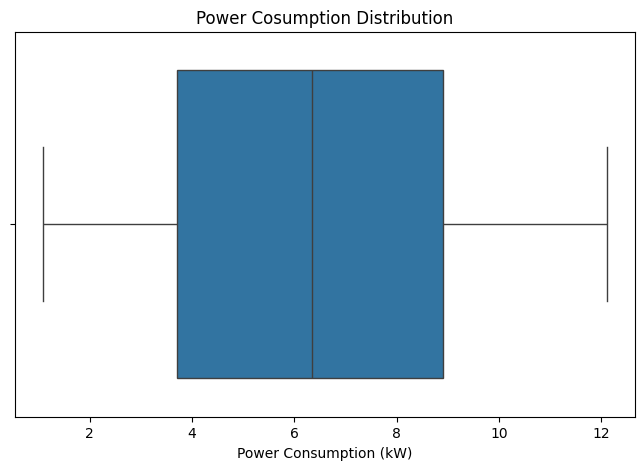

In [39]:
plt.figure(figsize=(8,5))
sn.boxplot(x=sg['Power Consumption (kW)'])
plt.title('Power Cosumption Distribution')

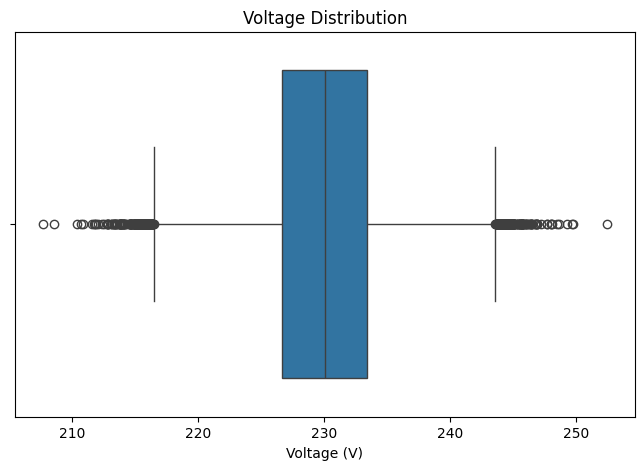

In [40]:
plt.figure(figsize=(8,5))
sn.boxplot(x=sg['Voltage (V)'])
plt.title('Voltage Distribution')
plt.show()

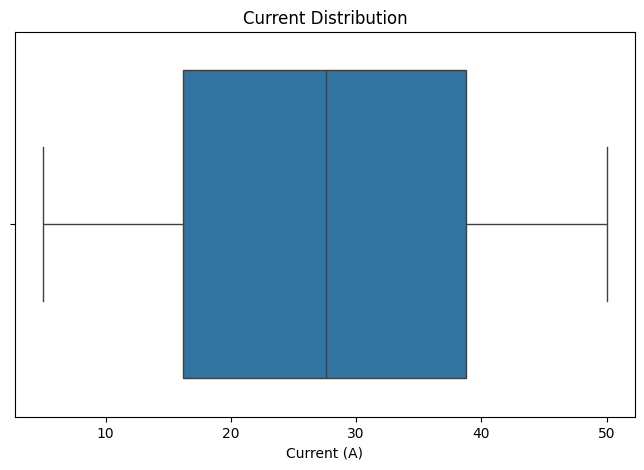

In [41]:
plt.figure(figsize=(8, 5))
sn.boxplot(x=sg['Current (A)'])
plt.title('Current Distribution')
plt.show()

In [42]:
sg['Transformer Fault'].value_counts()

,count
Transformer Fault,
0,48540
1,1460


In [43]:
sg['Transformer Fault'].unique()

array([0, 1])

In [44]:
sg['Overload Condition'].value_counts()

,count
Overload Condition,
0,45044
1,4956


In [45]:
sg['Overload Condition'] = (
    sg['Overload Condition'].astype('category')
)
sg['Transformer Fault'] = (
    sg['Transformer Fault'].astype('category')
)

In [46]:
sg.dtypes

,0
Timestamp,object
Voltage (V),float64
Current (A),float64
Power Consumption (kW),float64
Reactive Power (kVAR),float64
Power Factor,float64
Solar Power (kW),float64
Wind Power (kW),float64
Grid Supply (kW),float64
Voltage Fluctuation (%),float64


In [47]:
sg['renewable_power'] = (
    sg['Solar Power (kW)'] + sg['Wind Power (kW)']
)

In [48]:
sg[
    ['Solar Power (kW)','Wind Power (kW)','renewable_power']
    ].head()

,Solar Power (kW),Wind Power (kW),renewable_power
0,46.614845,26.399566,73.014411
1,6.907170,18.555011,25.462181
2,15.477640,12.905025,28.382665
3,35.746398,28.937129,64.683527
4,27.555038,14.184648,41.739686


In [49]:
sg['total_supply'] = (
    sg['Solar Power (kW)'] + sg['Wind Power (kW)'] + sg['Grid Supply (kW)']
)

In [50]:
sg['renewable_contribution'] = np.where(
    sg['total_supply'] != 0,
    (sg['renewable_power'] / sg['total_supply'])*100,0
)

In [51]:
sg['renewable_contribution'].describe()

,renewable_contribution
count,50000.000000
mean,99.448623
std,5.236730
min,2.094852
25%,100.000000
50%,100.000000
75%,100.000000
max,100.000000


In [52]:
sg['grid_dependency'] = np.where(
    sg['total_supply'] != 0,
    (sg['Grid Supply (kW)'] /
     sg['total_supply']) * 100,
    0
)

In [53]:
sg['renewable_grid_ratio'] = np.where(
    sg['Grid Supply (kW)'] !=0,
    sg['renewable_power'] / sg['Grid Supply (kW)'],
    np.nan
)

In [54]:
sg['apparent_power'] = (
    sg['Voltage (V)']*sg['Current (A)']
)


In [55]:
sg['apparent_power'] = (
    np.sqrt(3)*sg['Voltage (V)']*sg['Current (A)']
)

In [56]:
sg['Calculated_PF'] = np.where(
    sg['apparent_power'] != 0,
    (sg['Power Consumption (kW)'] / sg['apparent_power']),
    np.nan
)

In [57]:
sg[['Power Factor', 'Calculated_PF']].head(10)

,Power Factor,Calculated_PF
0,0.907766,0.000577
1,0.831813,0.000577
2,0.999005,0.000577
3,0.896462,0.000577
4,0.870681,0.000577
5,0.970003,0.000577
6,0.962855,0.000577
7,0.846779,0.000577
8,0.968598,0.000577
9,0.856682,0.000577


In [58]:
sg['reactive_active_ratio']= np.where(
    sg['Power Consumption (kW)'] != 0,
    (sg['Reactive Power (kVAR)'].abs() / sg['Power Consumption (kW)']),
    np.nan

)

In [59]:
sg['Load_stress'] = (
    sg['Power Consumption (kW)']/sg['Power Consumption (kW)'].quantile(0.95)
)

In [60]:
sg['load_stress_level'] = pd.cut(
    sg['Load_stress'],
    bins = [-np.inf,0.5,0.8,1.0,np.inf],
    labels = ['low','medium','high','very high']

)

In [61]:
sg['Overload_flag'] = sg['Overload Condition'].astype(int)

In [62]:
sg[
    ['Overload Condition','Overload_flag']
].head()

,Overload Condition,Overload_flag
0,0,0
1,1,1
2,0,0
3,0,0
4,0,0


In [63]:
sg.head()

,Timestamp,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),...,total_supply,renewable_contribution,grid_dependency,renewable_grid_ratio,apparent_power,Calculated_PF,reactive_active_ratio,Load_stress,load_stress_level,Overload_flag
0,2024-01-01 00:00:00,232.483571,5.124673,1.191402,0.399029,0.907766,46.614845,26.399566,0.0,1.055937,...,73.014411,100.0,0.0,NaN,2063.569174,0.000577,0.334924,0.108731,low,0
1,2024-01-01 00:15:00,229.308678,22.213519,5.093753,1.248030,0.831813,6.907170,18.555011,0.0,-3.910902,...,25.462181,100.0,0.0,NaN,8822.638328,0.000577,0.245012,0.464873,low,1
2,2024-01-01 00:30:00,233.238443,46.132217,10.759806,2.790464,0.999005,15.477640,12.905025,0.0,-0.197551,...,28.382665,100.0,0.0,NaN,18636.531516,0.000577,0.259341,0.981977,high,0
3,2024-01-01 00:45:00,237.615149,47.648972,11.322118,1.956965,0.896462,35.746398,28.937129,0.0,2.671921,...,64.683527,100.0,0.0,NaN,19610.482789,0.000577,0.172844,1.033296,very high,0
4,2024-01-01 01:00:00,228.829233,7.410166,1.695663,0.624718,0.870681,27.555038,14.184648,0.0,3.826937,...,41.739686,100.0,0.0,NaN,2936.973851,0.000577,0.368421,0.154752,low,0


In [64]:
sg.shape

(50000, 27)

In [65]:
sg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Timestamp                    50000 non-null  object  
 1   Voltage (V)                  50000 non-null  float64 
 2   Current (A)                  50000 non-null  float64 
 3   Power Consumption (kW)       50000 non-null  float64 
 4   Reactive Power (kVAR)        50000 non-null  float64 
 5   Power Factor                 50000 non-null  float64 
 6   Solar Power (kW)             50000 non-null  float64 
 7   Wind Power (kW)              50000 non-null  float64 
 8   Grid Supply (kW)             50000 non-null  float64 
 9   Voltage Fluctuation (%)      50000 non-null  float64 
 10  Overload Condition           50000 non-null  category
 11  Transformer Fault            50000 non-null  category
 12  Temperature (°C)             50000 non-null  float64 
 13  H

In [66]:
sg.to_csv(
    '/content/sample_data/smart_grid_dataset_cleaned.csv',
    index = False
)

In [67]:
import os
os.path.exists('/content/sample_data/smart_grid_dataset_cleaned.csv')

True

In [ ]:
from google.colab import files
files.download('/content/sample_data/smart_grid_dataset_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
sg = pd.read_csv('/content/sample_data/smart_grid_dataset_cleaned.csv')

In [69]:
sg.shape


(50000, 27)

In [70]:
sg.describe()

,Voltage (V),Current (A),Power Consumption (kW),Reactive Power (kVAR),Power Factor,Solar Power (kW),Wind Power (kW),Grid Supply (kW),Voltage Fluctuation (%),Overload Condition,...,renewable_power,total_supply,renewable_contribution,grid_dependency,renewable_grid_ratio,apparent_power,Calculated_PF,reactive_active_ratio,Load_stress,Overload_flag
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,813.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000
mean,229.997896,27.482627,6.320811,1.584137,0.899997,25.075357,15.008312,0.047198,-0.002723,0.099120,...,40.083668,40.130867,99.448623,0.551377,13.415563,10947.966505,5.773503e-04,0.250407,0.576859,0.099120
std,5.000849,12.984307,2.990096,0.964876,0.057740,14.434644,8.663070,0.460281,2.884219,0.298826,...,16.855153,16.761706,5.236730,5.236730,58.862673,5178.997878,1.078792e-16,0.086666,0.272886,0.298826
min,207.671981,5.001239,1.089178,0.113665,0.800001,0.000115,0.000067,0.000000,-4.999913,0.000000,...,0.120059,1.126929,2.094852,0.000000,0.021397,1886.510971,5.773503e-04,0.100002,0.099402,0.000000
25%,226.606874,16.144764,3.706998,0.805235,0.849930,12.597064,7.495573,0.000000,-2.506506,0.000000,...,27.465647,27.465647,100.000000,0.000000,0.955923,6420.708772,5.773503e-04,0.175111,0.338313,0.000000
50%,230.008697,27.580058,6.340475,1.386541,0.900119,25.031922,15.035654,0.000000,-0.009397,0.000000,...,40.192556,40.192556,100.000000,0.000000,2.275662,10982.025114,5.773503e-04,0.250520,0.578654,0.000000
75%,233.385302,38.778588,8.914134,2.209433,0.949748,37.527215,22.528948,0.000000,2.493917,0.000000,...,52.635363,52.635363,100.000000,0.000000,6.381125,15439.732137,5.773503e-04,0.325324,0.813535,0.000000
max,252.395421,49.999642,12.103199,4.684119,0.999997,49.998963,29.997815,10.766046,4.999946,1.000000,...,79.782126,79.782126,100.000000,97.905148,873.844693,20963.356083,5.773503e-04,0.399997,1.104580,1.000000


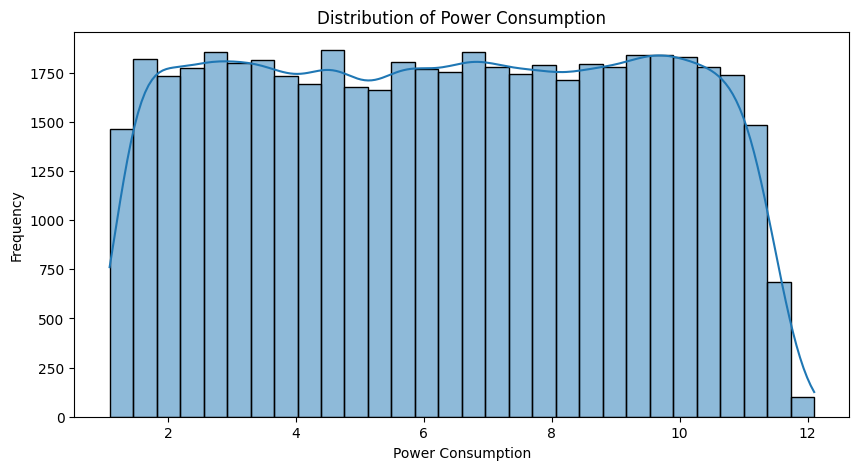

In [71]:
plt.figure(figsize=(10,5))
sn.histplot(sg['Power Consumption (kW)'],bins =30, kde = True)
plt.title('Distribution of Power Consumption')
plt.xlabel('Power Consumption')
plt.ylabel('Frequency')
plt.show()

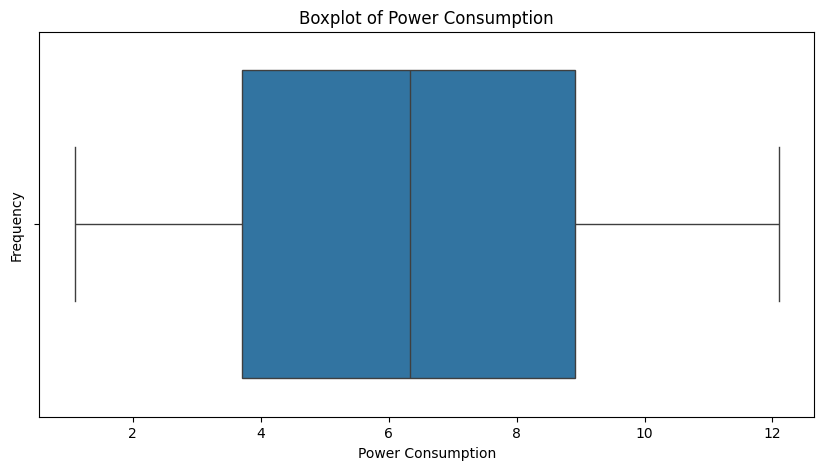

In [72]:
plt.figure(figsize = (10,5))
sn.boxplot(
    x = sg['Power Consumption (kW)']
)
plt.title('Boxplot of Power Consumption')
plt.xlabel('Power Consumption')
plt.ylabel('Frequency')
plt.show()

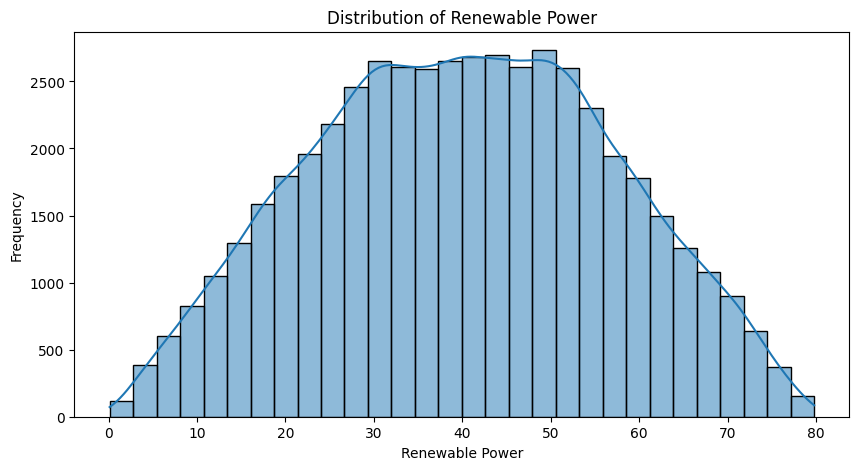

In [73]:
plt.figure(figsize=(10,5))
sn.histplot(sg['renewable_power'],
            bins =30, kde = True)
plt.title('Distribution of Renewable Power')
plt.xlabel('Renewable Power')
plt.ylabel('Frequency')
plt.show()

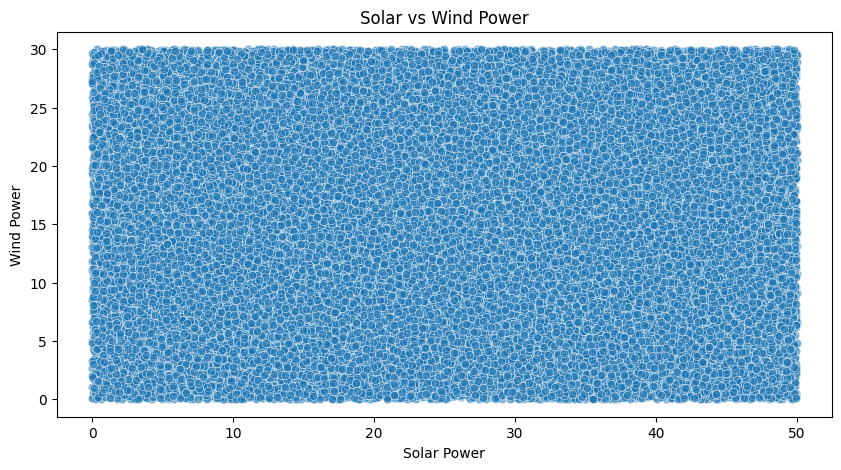

In [74]:
plt.figure(figsize=(10,5))
sn.scatterplot(
    data = sg,
    x = 'Solar Power (kW)',
    y = 'Wind Power (kW)',
    alpha = 0.6
)
plt.title('Solar vs Wind Power')
plt.xlabel('Solar Power')
plt.ylabel('Wind Power')
plt.show()


In [75]:
renewable_summary = pd.DataFrame({
    'Source':['Solar','Wind'],
    'Average Power':[
        sg['Solar Power (kW)'].mean(),
        sg['Wind Power (kW)'].mean()
    ]
})

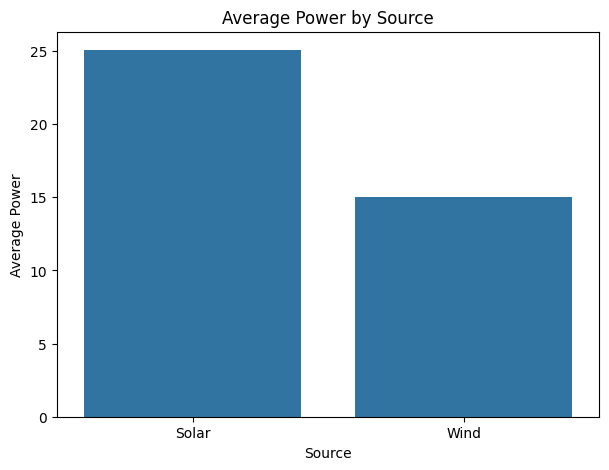

In [76]:
plt.figure(figsize=(7,5))
sn.barplot(data = renewable_summary,
           x = 'Source',
           y = 'Average Power')
plt.title('Average Power by Source')
plt.xlabel('Source')
plt.ylabel('Average Power')
plt.show()

In [77]:
sg['grid_dependency']

,grid_dependency
0,0.000000
1,0.000000
2,0.000000
3,0.000000
4,0.000000
...,...
49995,5.153398
49996,0.000000
49997,0.000000
49998,0.000000


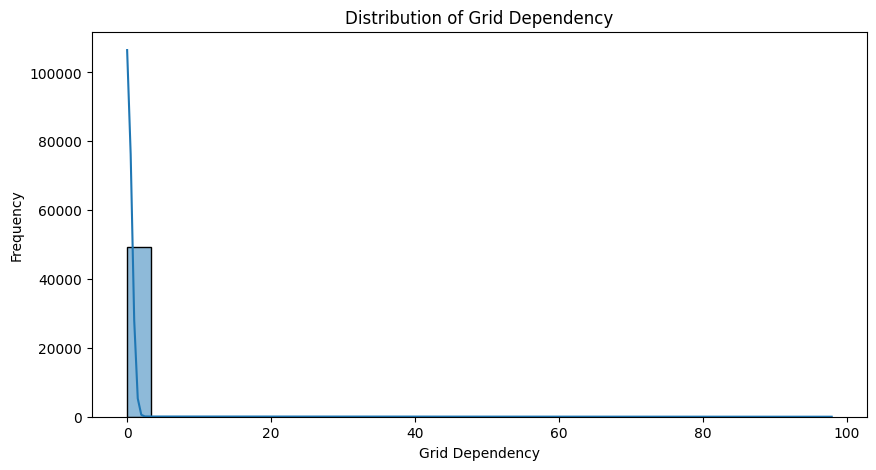

In [78]:
plt.figure(figsize=(10,5))
sn.histplot(
    sg['grid_dependency'],
    bins = 30,
    kde = True
)
plt.title('Distribution of Grid Dependency')
plt.xlabel('Grid Dependency')
plt.ylabel('Frequency')
plt.show()


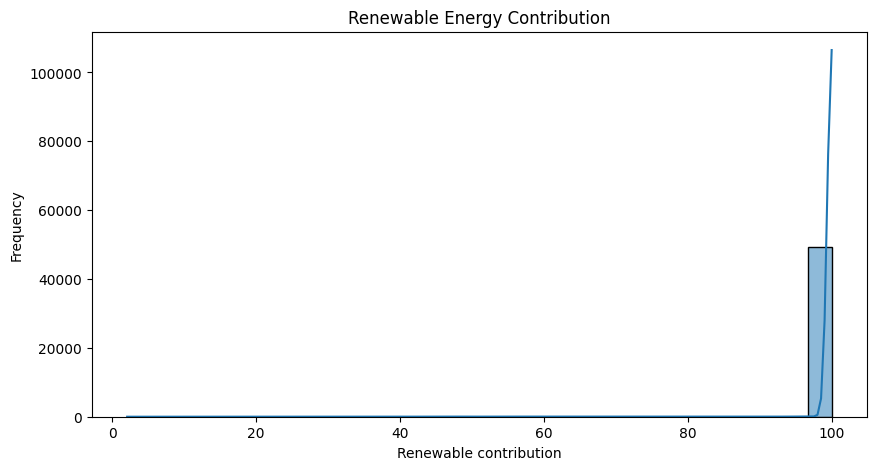

In [79]:
plt.figure(figsize= (10,5))
sn.histplot(
    sg['renewable_contribution'],
    bins = 30,
    kde = True
)
plt.title('Renewable Energy Contribution')
plt.xlabel('Renewable contribution')
plt.ylabel('Frequency')
plt.show()

In [80]:
sg['renewable_contribution'].mean()

np.float64(99.44862339765133)

In [81]:
Transformer_consumption = (
    sg.groupby('Transformer Fault')
    ['Power Consumption (kW)']
    .agg(['mean','median','std'])
    .sort_values('mean',ascending = False)

)

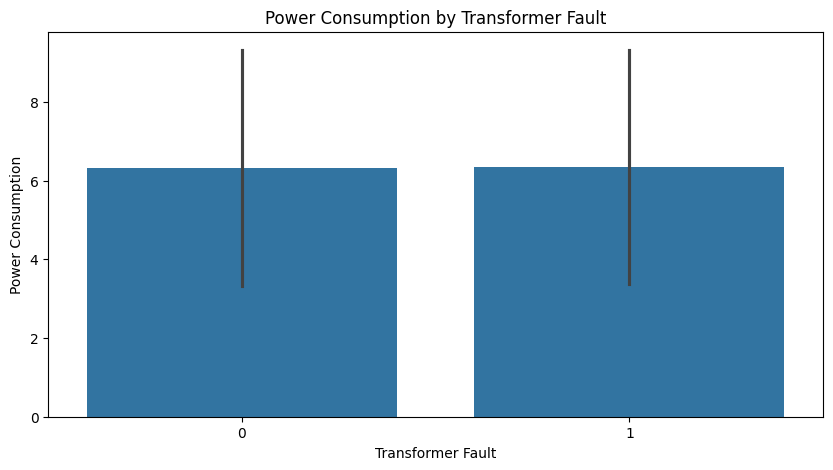

In [82]:
plt.figure(figsize=(10,5))
sn.barplot(
    data = sg,
    x='Transformer Fault',
    y = 'Power Consumption (kW)',
    estimator = 'mean',
    errorbar = 'sd'

)
plt.title('Power Consumption by Transformer Fault')
plt.xlabel('Transformer Fault')
plt.ylabel('Power Consumption')
plt.show()

In [83]:
Overload_by_transformer = (
    sg.groupby('Transformer Fault')
    ['Overload_flag']
    .mean().mul(100)
    .sort_values(ascending = False)
)

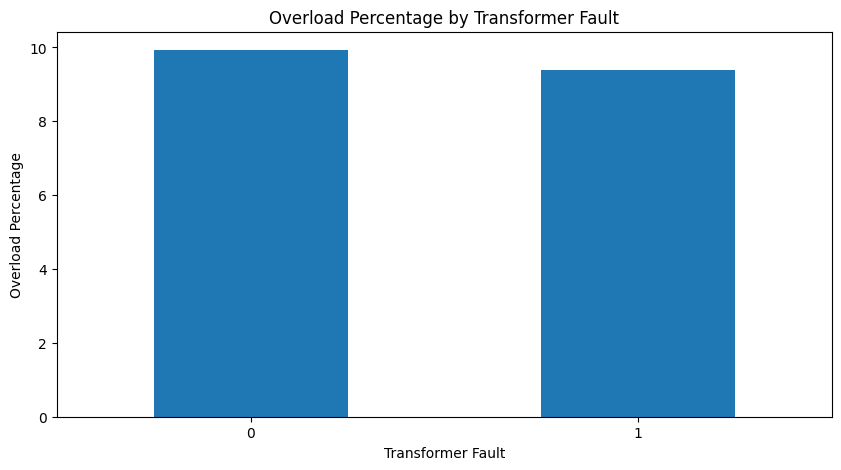

In [84]:
plt.figure(figsize=(10,5))
Overload_by_transformer.plot(
    kind = 'bar',
    xlabel = 'Transformer Fault',
    ylabel = 'Overload Percentage',
    title = 'Overload Percentage by Transformer Fault'
)
plt.xticks(rotation = 0)
plt.show()

In [85]:
sg.groupby(
    'Overload Condition'
)['Power Consumption (kW)'].agg(['mean','median','std','max','min']
)

,mean,median,std,max,min
Overload Condition,,,,,
0,6.319921,6.339654,2.988408,12.103199,1.089178
1,6.328904,6.355272,3.005686,11.937422,1.119456


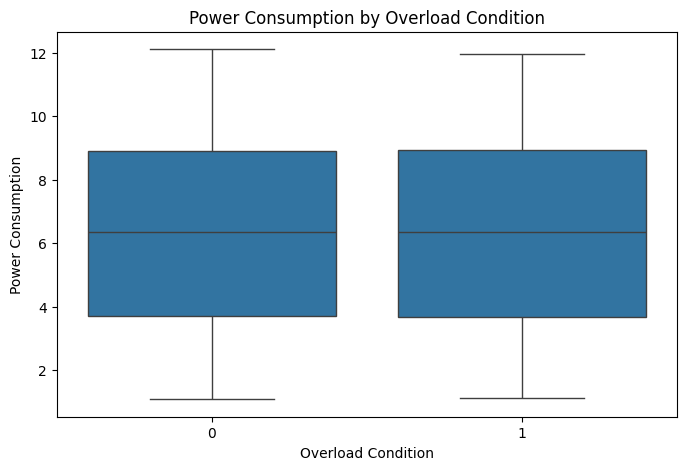

In [86]:
plt.figure(figsize=(8,5))
sn.boxplot(
    data = sg,
    x = 'Overload Condition',
    y = 'Power Consumption (kW)'
)
plt.title('Power Consumption by Overload Condition')
plt.xlabel('Overload Condition')
plt.ylabel('Power Consumption')
plt.show()


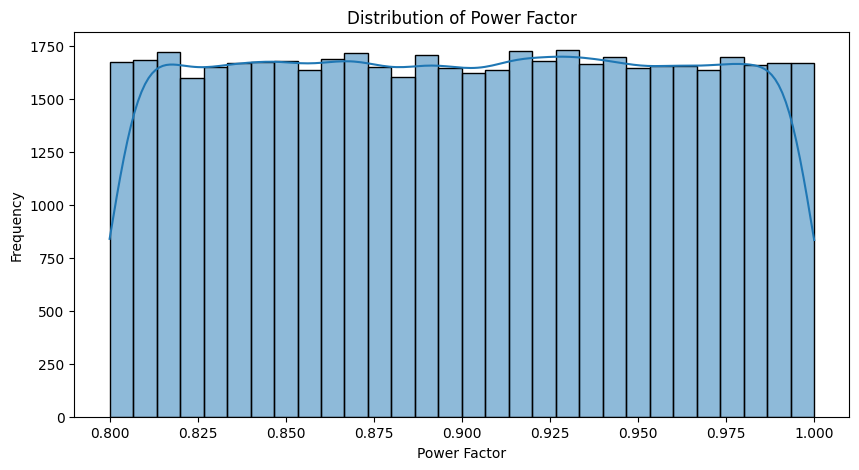

In [87]:
plt.figure(figsize = (10,5))
sn.histplot(
    sg['Power Factor'],
    bins = 30,
    kde = True
)
plt.title('Distribution of Power Factor')
plt.xlabel('Power Factor')
plt.ylabel('Frequency')
plt.show()


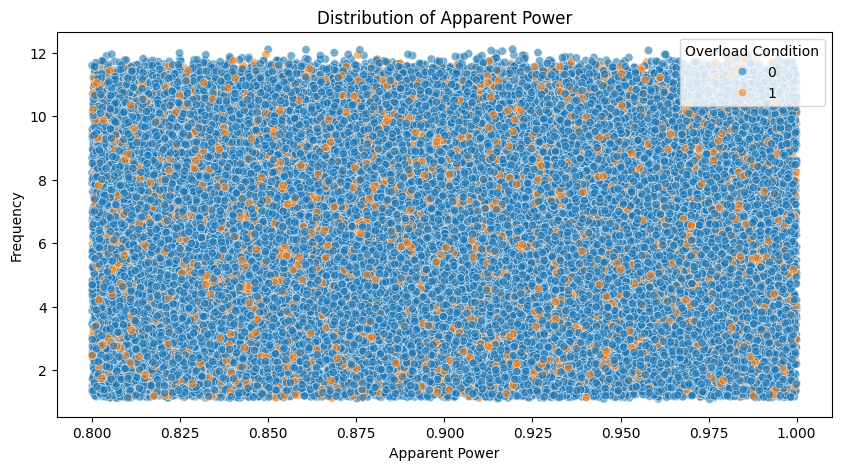

In [88]:
plt.figure(figsize=(10,5))
sn.scatterplot(
    data = sg,
    y = 'Power Consumption (kW)',
    x = 'Power Factor',
    hue = 'Overload Condition',
    alpha = 0.6
)
plt.title('Distribution of Apparent Power')
plt.xlabel('Apparent Power')
plt.ylabel('Frequency')
plt.show()

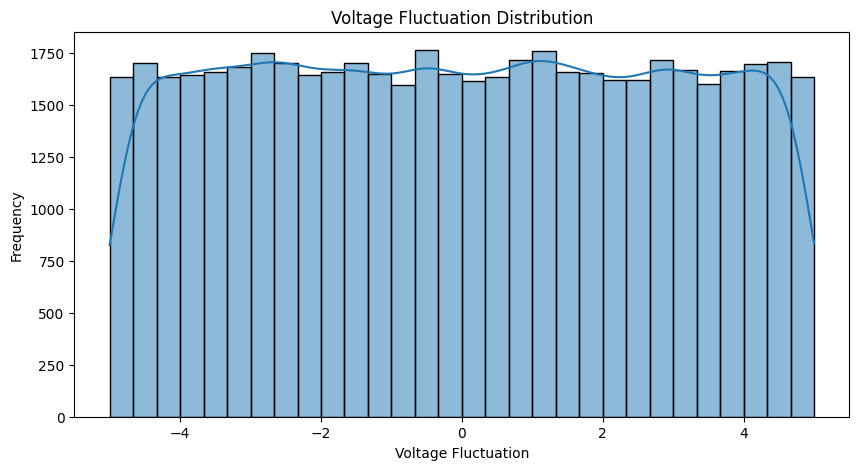

In [89]:
plt.figure(figsize=(10, 5))

sn.histplot(
    sg['Voltage Fluctuation (%)'],
    bins=30,
    kde=True
)

plt.title('Voltage Fluctuation Distribution')
plt.xlabel('Voltage Fluctuation')
plt.ylabel('Frequency')

plt.show()


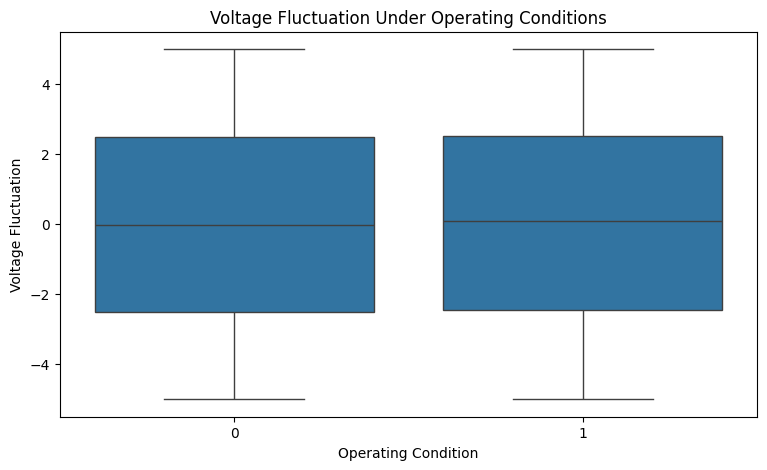

In [90]:
plt.figure(figsize=(9, 5))

sn.boxplot(
    data=sg,
    x='Overload Condition',
    y='Voltage Fluctuation (%)'
)

plt.title('Voltage Fluctuation Under Operating Conditions')
plt.xlabel('Operating Condition')
plt.ylabel('Voltage Fluctuation')

plt.show()

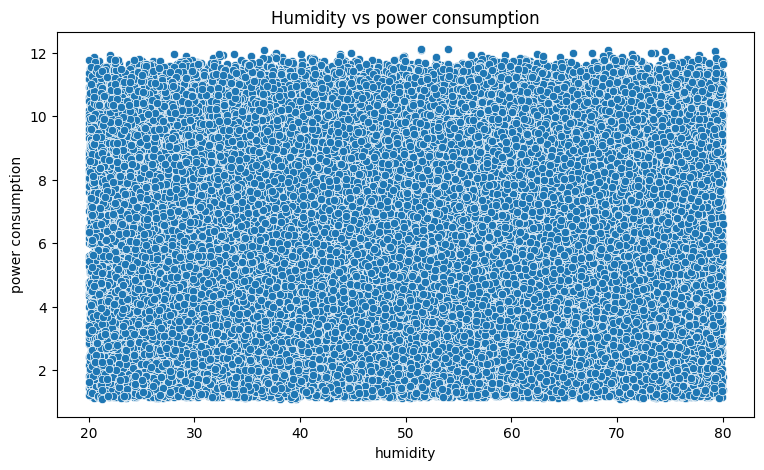

In [91]:
plt.figure(figsize=(9, 5))

sn.scatterplot(
    data=sg,
    x='Humidity (%)',
    y='Power Consumption (kW)'
)

plt.title("Humidity vs power consumption")
plt.xlabel('humidity')
plt.ylabel('power consumption')

plt.show()

In [92]:
sg[['Humidity (%)','Power Consumption (kW)']].corr()

,Humidity (%),Power Consumption (kW)
Humidity (%),1.000000,0.000724
Power Consumption (kW),0.000724,1.000000


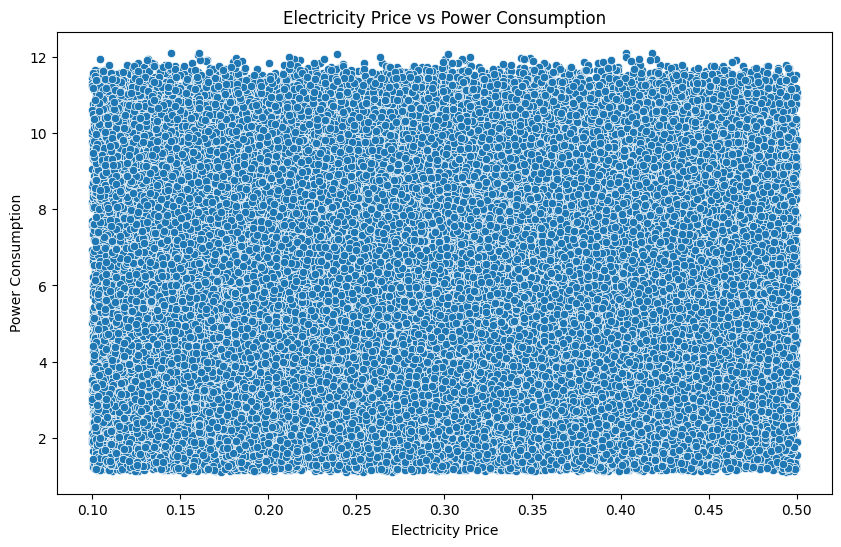

In [93]:
plt.figure(figsize=(10, 6))

sn.scatterplot(
    data=sg,
    x='Electricity Price (USD/kWh)',
    y='Power Consumption (kW)'
)

plt.title('Electricity Price vs Power Consumption')
plt.xlabel('Electricity Price')
plt.ylabel('Power Consumption')

plt.show()


In [94]:
sg[['Electricity Price (USD/kWh)','Power Consumption (kW)']].corr()
#

,Electricity Price (USD/kWh),Power Consumption (kW)
Electricity Price (USD/kWh),1.000000,0.004907
Power Consumption (kW),0.004907,1.000000


In [95]:
corr = sg.select_dtypes(
    include = np.number
).corr()

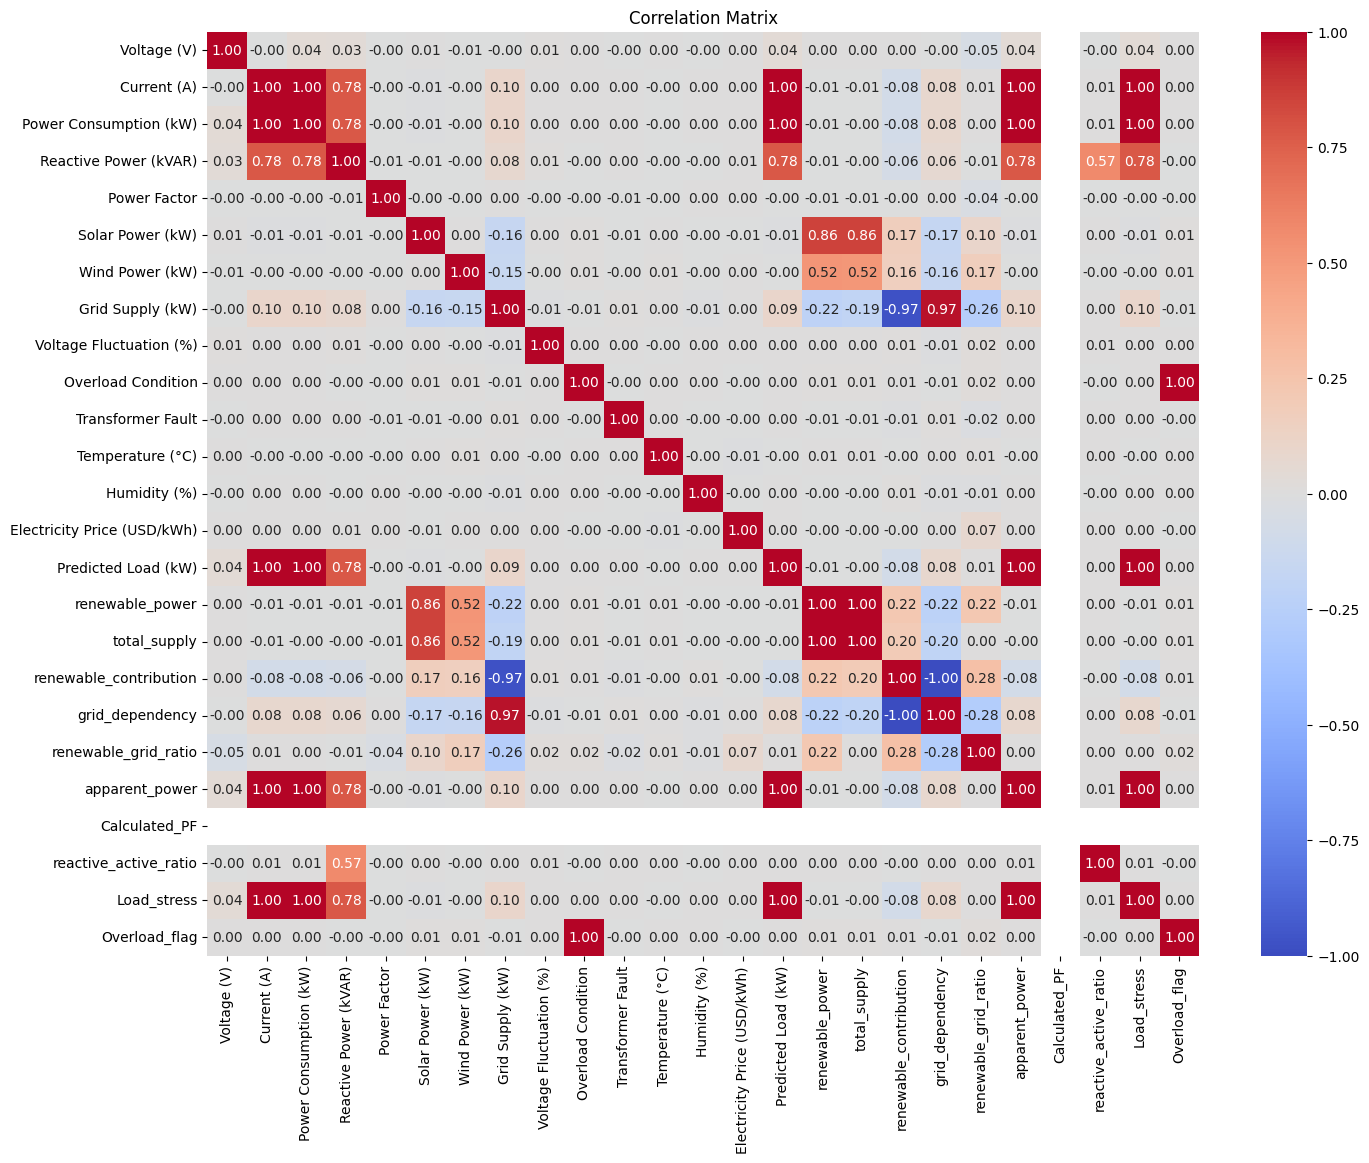

In [96]:
plt.figure(figsize=(16, 12))

sn.heatmap(
    corr,
    annot = True,
    fmt='.2f',
    cmap='coolwarm',
    center = 0
)

plt.title('Correlation Matrix')

plt.show()

In [97]:
target_corr =(
    corr['Power Consumption (kW)']
    .sort_values(ascending = False)
)


In [98]:
target_corr

,Power Consumption (kW)
Load_stress,1.000000
apparent_power,1.000000
Power Consumption (kW),1.000000
Current (A),0.998715
Predicted Load (kW),0.997735
Reactive Power (kVAR),0.778545
Grid Supply (kW),0.095213
grid_dependency,0.078851
Voltage (V),0.043699
reactive_active_ratio,0.005260


In [99]:
Overload_analysis = sg.groupby('Overload Condition')[[
    'Power Consumption (kW)','Current (A)','Voltage (V)','Power Factor','Reactive Power (kVAR)'
]].mean()

In [100]:
top_consumption = sg.nlargest(
    10,'Power Consumption (kW)'
)

In [101]:
high_consumption_threshold = (
    sg['Power Consumption (kW)'].quantile(0.95)
)

sg['high_consumption_flag'] = (
    sg['Power Consumption (kW)']
    >= high_consumption_threshold
).astype(int)

In [102]:
sg['high_consumption_flag'].value_counts()

,count
high_consumption_flag,
0,47500
1,2500


In [103]:
pd.crosstab(
    sg['Overload Condition'],
    sg['high_consumption_flag'],
    normalize = 'index'
)* 100

high_consumption_flag,0,1
Overload Condition,,
0,94.984904,5.015096
1,95.137207,4.862793


In [104]:
sg.to_csv('/content/sample_data/smart_grid_dataset_cleaned.csv', index = False)

In [105]:
import scipy.stats as stats

In [106]:
sg.shape

(50000, 28)

In [107]:
normal = sg[sg['Overload Condition']==0]['Power Consumption (kW)'].dropna()

In [108]:
overload= sg[sg['Overload Condition'] == 1]['Power Consumption (kW)'].dropna()

In [109]:
print('Normal:', len(normal))
print('Overload:', len(overload))

Normal: 45044
Overload: 4956


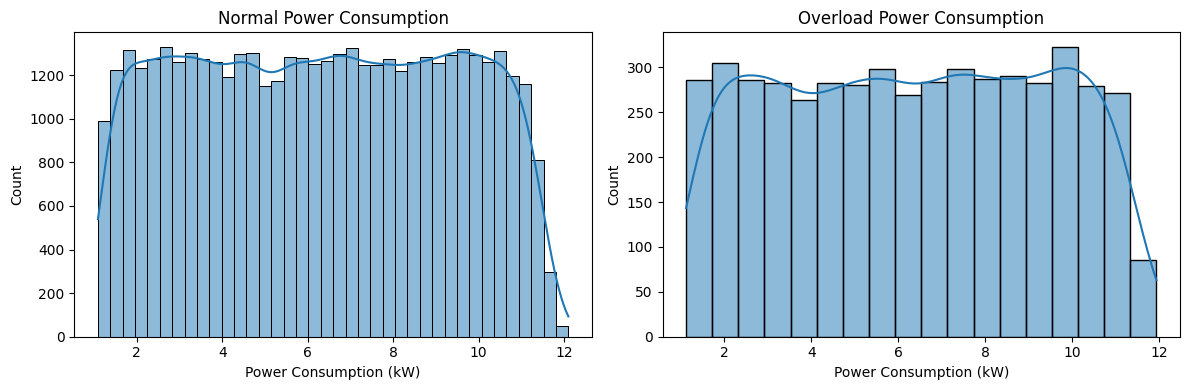

In [110]:
fig , axes = plt.subplots(1,2,figsize = (12,4))
sn.histplot(normal,ax=axes[0],kde =True)
axes[0].set_title('Normal Power Consumption')
sn.histplot(overload,ax=axes[1],kde =True)
axes[1].set_title('Overload Power Consumption')
plt.tight_layout()
plt.show()

In [111]:
mean_normal = normal.mean()
mean_overload = overload.mean()
difference = mean_overload - mean_normal

In [112]:
percentage_difference = (
    (mean_overload - mean_normal) / mean_normal
)*100
print('Percentage differnece:', percentage_difference)

Percentage differnece: 0.14213657122993578


In [113]:
normal_pf = sg[sg['Overload Condition']==0]['Power Factor'].dropna()
overload_pf = sg[sg['Overload Condition']==1]['Power Factor'].dropna()

In [114]:
t_stat_pf, p_valur_pf = stats.ttest_ind(
    normal_pf,
    overload_pf ,
     equal_var =False
)

In [115]:
if p_valur_pf < 0.05:
    print('Power Factor differs significantly between normal and overload conditions')
else:
    print('Power Factor does not differ significantly between normal and overload conditions.')

Power Factor does not differ significantly between normal and overload conditions.


In [116]:
print("Normal PF:", normal_pf.mean())
print("Overload PF:", overload_pf.mean())

Normal PF: 0.9000425426822278
Overload PF: 0.8995867654708773


In [117]:
pf_difference = (
    overload_pf.mean() -
    normal_pf.mean()
)

print("PF difference:", pf_difference)

PF difference: -0.0004557772113504832


In [118]:
normal_vf = sg[
    sg['Overload Condition'] == 0
]['Voltage Fluctuation (%)'].dropna()

overload_vf = sg[
    sg['Overload Condition'] == 1
]['Voltage Fluctuation (%)'].dropna()

In [119]:
rho, p_spearman = stats.spearmanr(
    sg['Temperature (°C)'],
    sg['Power Consumption (kW)']
)

print("Spearman correlation:", rho)
print("p-value:", p_spearman)

Spearman correlation: -0.004546665403290667
p-value: 0.30932227767759113


In [120]:
r_price, p_price = stats.pearsonr(
    sg['Electricity Price (USD/kWh)'],
    sg['Power Consumption (kW)']
)

print("Correlation:", r_price)
print("p-value:", p_price)

Correlation: 0.004907339135664314
p-value: 0.2725130839919393


In [121]:
rho_price, p_price_s = stats.spearmanr(
    sg['Electricity Price (USD/kWh)'],
    sg['Power Consumption (kW)']
)

print("Spearman Correlation:", rho_price)
print("p-value:", p_price_s)

Spearman Correlation: 0.004914440599821776
p-value: 0.2718197625212645


In [122]:
r_renewable, p_renewable = stats.pearsonr(
    sg['renewable_power'],
    sg['grid_dependency']
)

print("Correlation:", r_renewable)
print("p-value:", p_renewable)

Correlation: -0.2236762895460619
p-value: 0.0


In [123]:
transformer_groups = [
    group['Power Consumption (kW)'].dropna().values
    for _, group in sg.groupby('Transformer Fault')
]

In [124]:
f_stat, p_value_anova = stats.f_oneway(
    *transformer_groups
)
print('F-statistic:',f_stat)
print('p-value:',p_value_anova)

F-statistic: 0.06913117926629117
p-value: 0.7926070903302216


In [125]:
contingency_table = pd.crosstab(
    sg['Transformer Fault'],
    sg['Overload Condition']
)

contingency_table

Overload Condition,0,1
Transformer Fault,,
0,43721,4819
1,1323,137


In [126]:
chi2, p_value_chi, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-square:", chi2)
print("p-value:", p_value_chi)
print("Degrees of freedom:", dof)

Chi-square: 0.41132573797121424
p-value: 0.5212973790053536
Degrees of freedom: 1


In [127]:
data = sg['Power Consumption (kW)'].dropna()

n = len(data)
mean = data.mean()
sem = stats.sem(data)

confidence_interval = stats.t.interval(
    0.95,
    df=n-1,
    loc=mean,
    scale=sem
)

print("Mean:", mean)
print("95% Confidence Interval:", confidence_interval)

Mean: 6.320811408951385
95% Confidence Interval: (np.float64(6.2946019106393285), np.float64(6.347020907263441))


In [128]:
def significance_result(p_value, alpha=0.05):
    if p_value < alpha:
        return "Statistically significant"
    else:
        return "Not statistically significant"

In [129]:
print(sg.columns.tolist())

['Timestamp', 'Voltage (V)', 'Current (A)', 'Power Consumption (kW)', 'Reactive Power (kVAR)', 'Power Factor', 'Solar Power (kW)', 'Wind Power (kW)', 'Grid Supply (kW)', 'Voltage Fluctuation (%)', 'Overload Condition', 'Transformer Fault', 'Temperature (°C)', 'Humidity (%)', 'Electricity Price (USD/kWh)', 'Predicted Load (kW)', 'renewable_power', 'total_supply', 'renewable_contribution', 'grid_dependency', 'renewable_grid_ratio', 'apparent_power', 'Calculated_PF', 'reactive_active_ratio', 'Load_stress', 'load_stress_level', 'Overload_flag', 'high_consumption_flag']


In [130]:
sg.columns = [
    'timestamp',
    'voltage',
    'current',
    'power_consumption',
    'reactive_power',
    'power_factor',
    'solar_power',
    'wind_power',
    'grid_supply',
    'voltage_fluctuations',
    'overload_condition',
    'transformer_fault',
    'temperature',
    'humidity',
    'electricity_price',
    'predicted_load',
    'renewable_power',
    'total_supply',
    'renewable_contribution',
    'grid_dependency',
    'renewable_grid_ratio',
    'apparent_power',
    'calculated_pf',
    'reactive_active_ratio',
    'load_stress',
    'load_stress_level',
    'overload_flag',
    'high_consumption_flag'
]

In [131]:
sg.columns.tolist()

['timestamp',
 'voltage',
 'current',
 'power_consumption',
 'reactive_power',
 'power_factor',
 'solar_power',
 'wind_power',
 'grid_supply',
 'voltage_fluctuations',
 'overload_condition',
 'transformer_fault',
 'temperature',
 'humidity',
 'electricity_price',
 'predicted_load',
 'renewable_power',
 'total_supply',
 'renewable_contribution',
 'grid_dependency',
 'renewable_grid_ratio',
 'apparent_power',
 'calculated_pf',
 'reactive_active_ratio',
 'load_stress',
 'load_stress_level',
 'overload_flag',
 'high_consumption_flag']

In [132]:
sg['timestamp'].head()

,timestamp
0,2024-01-01 00:00:00
1,2024-01-01 00:15:00
2,2024-01-01 00:30:00
3,2024-01-01 00:45:00
4,2024-01-01 01:00:00


In [133]:
sg['timestamp']= pd.to_datetime(
    sg['timestamp'],
    errors = 'coerce'
)

In [134]:
sg['timestamp'].isna().sum()

np.int64(0)

In [135]:
sg.to_csv('/content/sample_data/smart_grid_dataset_cleaned.csv', index = False)

In [136]:
from google.colab import files
files.download('/content/sample_data/smart_grid_dataset_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Machine Learning

In [137]:
import pandas as pd
import numpy as np
sg = pd.read_csv('/content/sample_data/smart_grid_dataset_cleaned.csv')

In [138]:
sg.head()

,timestamp,voltage,current,power_consumption,reactive_power,power_factor,solar_power,wind_power,grid_supply,voltage_fluctuations,...,renewable_contribution,grid_dependency,renewable_grid_ratio,apparent_power,calculated_pf,reactive_active_ratio,load_stress,load_stress_level,overload_flag,high_consumption_flag
0,2024-01-01 00:00:00,232.483571,5.124673,1.191402,0.399029,0.907766,46.614845,26.399566,0.0,1.055937,...,100.0,0.0,NaN,2063.569174,0.000577,0.334924,0.108731,low,0,0
1,2024-01-01 00:15:00,229.308678,22.213519,5.093753,1.248030,0.831813,6.907170,18.555011,0.0,-3.910902,...,100.0,0.0,NaN,8822.638328,0.000577,0.245012,0.464873,low,1,0
2,2024-01-01 00:30:00,233.238443,46.132217,10.759806,2.790464,0.999005,15.477640,12.905025,0.0,-0.197551,...,100.0,0.0,NaN,18636.531516,0.000577,0.259341,0.981977,high,0,0
3,2024-01-01 00:45:00,237.615149,47.648972,11.322118,1.956965,0.896462,35.746398,28.937129,0.0,2.671921,...,100.0,0.0,NaN,19610.482789,0.000577,0.172844,1.033296,very high,0,1
4,2024-01-01 01:00:00,228.829233,7.410166,1.695663,0.624718,0.870681,27.555038,14.184648,0.0,3.826937,...,100.0,0.0,NaN,2936.973851,0.000577,0.368421,0.154752,low,0,0


In [139]:
sg.shape

(50000, 28)

In [140]:
sg['power_consumption'].describe()

,power_consumption
count,50000.000000
mean,6.320811
std,2.990096
min,1.089178
25%,3.706998
50%,6.340475
75%,8.914134
max,12.103199


In [141]:
sg['power_consumption'].isnull().sum()

np.int64(0)

In [142]:
sg[['power_consumption','predicted_load']].describe()

,power_consumption,predicted_load
count,50000.000000,50000.000000
mean,6.320811,6.320693
std,2.990096,2.997199
min,1.089178,1.043487
25%,3.706998,3.711469
50%,6.340475,6.328723
75%,8.914134,8.910125
max,12.103199,12.483253


In [143]:
sg[
    ['power_consumption', 'predicted_load']
].corr()

,power_consumption,predicted_load
power_consumption,1.000000,0.997735
predicted_load,0.997735,1.000000


In [144]:
sg_ml = sg.copy()

sg_ml = sg_ml.drop(
    columns=['predicted_load']
)

In [145]:
sg_ml['timestamp'] = pd.to_datetime(
    sg_ml['timestamp'],
    errors='coerce'
)

In [146]:
sg_ml['hour'] = sg_ml['timestamp'].dt.hour
sg_ml['day'] = sg_ml['timestamp'].dt.day
sg_ml['month'] = sg_ml['timestamp'].dt.month
sg_ml['day_of_week'] = sg_ml['timestamp'].dt.dayofweek
sg_ml['is_weekend'] = (
    sg_ml['day_of_week'] >= 5
).astype(int)

In [147]:
sg_ml = sg_ml.drop(
    columns = ['timestamp']
)

In [148]:
sg_ml[['hour','day','month','day_of_week',"is_weekend"]].head()

,hour,day,month,day_of_week,is_weekend
0,0,1,1,0,0
1,0,1,1,0,0
2,0,1,1,0,0
3,0,1,1,0,0
4,1,1,1,0,0


In [149]:
sg_ml.select_dtypes(
    include = 'object'
).columns

Index(['load_stress_level'], dtype='object')

In [150]:
sg_ml= sg_ml.drop(
    columns= [
        'load_stress','load_stress_level'
    ], errors= 'ignore'
)

In [151]:
sg_ml = sg_ml.drop(
    columns=[
        'calculated_pf','reactive_active_ratio'
    ], errors='ignore'

)

In [152]:
y = sg_ml['power_consumption']
X = sg_ml.drop(columns=['power_consumption'])

In [153]:
X.shape, y.shape

((50000, 26), (50000,))

In [154]:
X.columns.tolist()

['voltage',
 'current',
 'reactive_power',
 'power_factor',
 'solar_power',
 'wind_power',
 'grid_supply',
 'voltage_fluctuations',
 'overload_condition',
 'transformer_fault',
 'temperature',
 'humidity',
 'electricity_price',
 'renewable_power',
 'total_supply',
 'renewable_contribution',
 'grid_dependency',
 'renewable_grid_ratio',
 'apparent_power',
 'overload_flag',
 'high_consumption_flag',
 'hour',
 'day',
 'month',
 'day_of_week',
 'is_weekend']

In [155]:
X =X.drop(
    columns=['predicted_load']
    , errors = 'ignore'
)

In [156]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [157]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (40000, 26)
Testing: (10000, 26)


In [158]:
categorical_features = X.select_dtypes(
    include = ['object','category']
).columns.tolist()

In [159]:
numerical_features = X.select_dtypes(
    include = np.number
).columns.tolist()

In [160]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.impute import SimpleImputer

In [161]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [162]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

In [163]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [164]:
from sklearn.dummy import DummyRegressor

baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyRegressor(strategy='mean'))
])

baseline_model.fit(
    X_train,
    y_train
)

baseline_pred = baseline_model.predict(X_test)

In [165]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    return mae, rmse, r2

In [166]:
baseline_mae, baseline_rmse, baseline_r2 = evaluate_model(
    baseline_model,
    X_test,
    y_test
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 2.585248142546757
Baseline RMSE: 2.9866359127395516
Baseline R²: -0.00035883347818099764


In [167]:
from sklearn.linear_model import LinearRegression
linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [168]:
linear_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['voltage', 'current',
                                                   'reactive_power',
                                                   'power_factor',
                                                   'solar_power', 'wind_power',
                                                   'grid_supply',
                                                   'voltage_fluctuations',
                                                   'overload_condition',
                                                   'transformer_fault',
                                                   'temperature', 'humidity',
                                                   'elec...
                                                   'total_supply',
                                                   'renewable_contribution',
                                                   'grid_dependency',
                                                   'renewable_grid_ratio',
                                                   'apparent_power',
                                                   'overload_flag',
                                                   'high_consumption_flag',
                                                   'hour', 'day', 'month',
                                                   'day_of_week',
                                                   'is_weekend']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('model', LinearRegression())])

In [169]:
linear_mae, linear_rmse, linear_r2 = evaluate_model(
    linear_model,
    X_test,
    y_test
)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 4.677014331377905e-15
RMSE: 6.374576929145061e-15
R²: 1.0


In [170]:
best_model = linear_model

In [171]:
y_pred = best_model.predict(X_test)

In [172]:
prediction_results = pd.DataFrame({
    'Actual_Load': y_test.values,
    "predicted_Load":y_pred
})

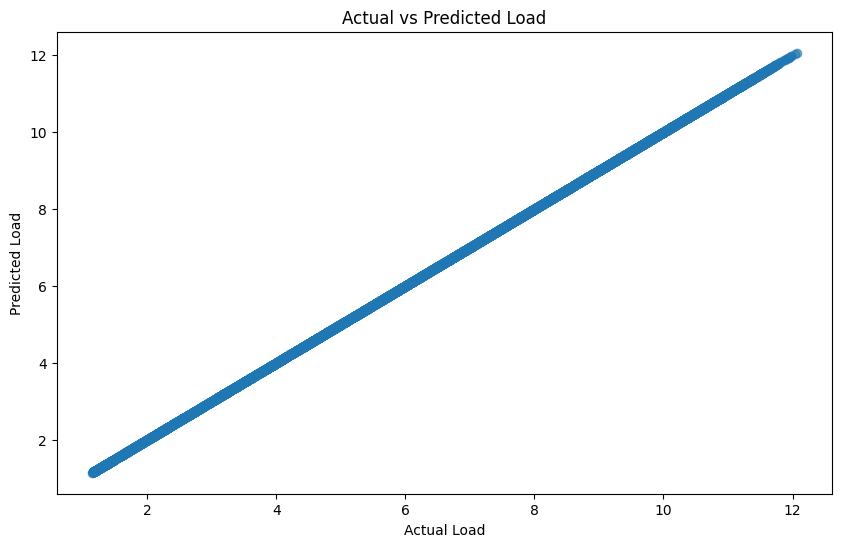

In [173]:
plt.figure(figsize=(10, 6))

plt.scatter(
    prediction_results['Actual_Load'],
    prediction_results['predicted_Load'],
    alpha=0.6
)

plt.xlabel('Actual Load')
plt.ylabel('Predicted Load')
plt.title('Actual vs Predicted Load')

plt.show()

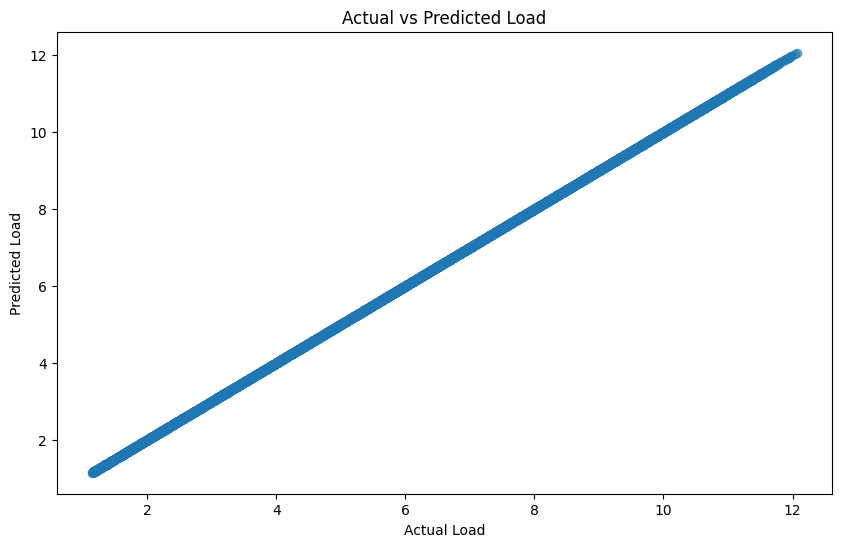

In [174]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Load')
plt.ylabel('Predicted Load')
plt.title('Actual vs Predicted Load')

plt.show()

In [175]:
prediction_results['error']=(
    prediction_results['Actual_Load']-
    prediction_results['predicted_Load']

)

In [176]:
prediction_results['absolute_error'] = (
    prediction_results['error'].abs()
)

In [177]:
prediction_results.sort_values(
    'absolute_error',
    ascending=False
).head(10)

,Actual_Load,predicted_Load,error,absolute_error
5376,3.462207,3.462207,3.552714e-14,3.552714e-14
6680,10.017305,10.017305,3.552714e-14,3.552714e-14
3933,5.869406,5.869406,3.463896e-14,3.463896e-14
6614,10.428070,10.428070,3.375078e-14,3.375078e-14
4901,6.748005,6.748005,3.286260e-14,3.286260e-14
4399,6.850558,6.850558,3.197442e-14,3.197442e-14
3004,8.241351,8.241351,3.197442e-14,3.197442e-14
5819,5.609066,5.609066,3.108624e-14,3.108624e-14
1138,4.965157,4.965157,3.108624e-14,3.108624e-14
5533,9.436198,9.436198,3.019807e-14,3.019807e-14


In [178]:
sg['timestamp'] = pd.to_datetime(
    sg['timestamp']
)

print(sg['timestamp'].min())
print(sg['timestamp'].max())

2024-01-01 00:00:00
2025-06-04 19:45:00


In [179]:
sg['timestamp'].sort_values().head()

,timestamp
0,2024-01-01 00:00:00
1,2024-01-01 00:15:00
2,2024-01-01 00:30:00
3,2024-01-01 00:45:00
4,2024-01-01 01:00:00


In [180]:
results = pd.DataFrame({
    'Model': ['Baseline Model', 'Linear Regression'],
    'MAE': [baseline_mae, linear_mae],
    'RMSE': [baseline_rmse, linear_rmse],
    'R2': [baseline_r2, linear_r2]
})

results.to_csv(
    '/content/ml_model_comparison.csv',
    index=False
)

In [181]:
prediction_results.to_csv(
    '/content/load_predictions.csv',
    index=False
)

In [182]:
print(sg['timestamp'].min())
print(sg['timestamp'].max())

2024-01-01 00:00:00
2025-06-04 19:45:00


In [183]:
sg[['power_consumption', 'predicted_load']].corr()

,power_consumption,predicted_load
power_consumption,1.000000,0.997735
predicted_load,0.997735,1.000000


In [184]:
sg[['power_consumption',
    'voltage',
    'current',
    'power_factor',
    'reactive_power',
    'apparent_power',
    'calculated_pf',
    'reactive_active_ratio']].corr()['power_consumption'].sort_values(
    ascending=False
)

,power_consumption
apparent_power,1.000000
power_consumption,1.000000
current,0.998715
reactive_power,0.778545
voltage,0.043699
reactive_active_ratio,0.005260
power_factor,-0.002893
calculated_pf,NaN


In [185]:
files.download('/content/sample_data/smart_grid_dataset_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

GenAI

In [186]:
import pandas as pd
import numpy as np
sg = pd.read_csv('/content/sample_data/smart_grid_dataset_cleaned (4).csv')


In [187]:
sg['timestamp']=pd.to_datetime(
    sg['timestamp'],
    errors='coerce'
)

In [188]:
summary = {
    'total_records': len(df),

    'avg_consumption':
        sg['power_consumption'].mean(),

    'peak_consumption':
        sg['power_consumption'].max(),

    'avg_voltage':
        sg['voltage'].mean(),

    'avg_current':
        sg['current'].mean(),

    'avg_power_factor':
        sg['power_factor'].mean(),

    'avg_reactive_power':
        sg['reactive_power'].mean(),

    'total_renewable_power':
        sg['renewable_power'].sum(),

    'total_grid_supply':
        sg['grid_supply'].sum(),

    'avg_renewable_contribution':
        sg['renewable_contribution'].mean(),

    'avg_grid_dependency':
        sg['grid_dependency'].mean(),

    'overload_events':
        (sg['overload_flag'] == 1).sum()
}

In [190]:
transformer_summary = (
    sg.groupby('transformer_fault')
    .agg(
        avg_load=('power_consumption', 'mean'),
        peak_load=('power_consumption', 'max'),
        avg_pf=('power_factor', 'mean'),
        avg_reactive_power=('reactive_power', 'mean'),
        avg_voltage_fluctuation=('voltage_fluctuations', 'mean'),
        overload_rate=('overload_flag', 'mean')
    )
    .reset_index()
)

In [191]:
highest_load_transformer = (
    transformer_summary
    .sort_values('avg_load', ascending=False)
    .iloc[0]
)


In [192]:
highest_overload_transformer = (
    transformer_summary
    .sort_values('overload_rate', ascending=False)
    .iloc[0]
)


In [193]:
lowest_pf_transformer = (
    transformer_summary
    .sort_values('avg_pf', ascending=True)
    .iloc[0]
)

In [194]:
highest_voltage_fluctuation = (
    transformer_summary
    .sort_values(
        'avg_voltage_fluctuation',
        ascending=False
    )
    .iloc[0]
)


In [196]:
sg['hour']=sg['timestamp'].dt.hour

In [197]:
hourly_load = (
    sg.groupby('hour')
    ['power_consumption']
    .mean()
    .reset_index()
)

In [198]:
peak_hour = hourly_load.loc[
    hourly_load['power_consumption'].idxmax()
]


In [199]:
overload_by_hour = (
    sg.groupby('hour')['overload_flag']
    .sum()
    .reset_index()
)

In [200]:
peak_overload_hour = overload_by_hour.loc[
    overload_by_hour['overload_flag'].idxmax()
]

In [201]:
renewable_total = sg['renewable_power'].sum()
grid_total = sg['grid_supply'].sum()
total_supply = sg['total_supply'].sum()

renewable_share = (
    renewable_total / total_supply
)

grid_share = (
    grid_total / total_supply
)

print("Renewable share:", renewable_share)
print("Grid share:", grid_share)

Renewable share: 0.9988238968865215
Grid share: 0.0011761031134784722


In [202]:
solar_total = sg['solar_power'].sum()
wind_total = sg['wind_power'].sum()

print("Solar:", solar_total)
print("Wind:", wind_total)

Solar: 1253767.8429729836
Wind: 750415.5801830168


In [203]:
ml_results = pd.read_csv(
    '/content/ml_model_comparison.csv'
)


In [204]:
best_model = ml_results.loc[
    ml_results['RMSE'].idxmin()
]


In [205]:
genai_report = f"""
SMART ENERGY ANALYTICS - VERIFIED RESULTS

DATASET
-------
Total records: {len(sg)}
Start date: {sg['timestamp'].min()}
End date: {sg['timestamp'].max()}

SYSTEM KPIs
-----------
Average consumption: {sg['power_consumption'].mean():.2f}
Peak consumption: {sg['power_consumption'].max():.2f}
Average voltage: {sg['voltage'].mean():.2f}
Average current: {sg['current'].mean():.2f}
Average power factor: {sg['power_factor'].mean():.4f}
Average reactive power: {sg['reactive_power'].mean():.2f}

ENERGY SUPPLY
-------------
Total renewable power: {renewable_total:.2f}
Total grid supply: {grid_total:.2f}
Renewable share of total supply: {renewable_share:.2%}
Grid share of total supply: {grid_share:.2%}

OVERLOAD
--------
Total overload events: {(sg['overload_flag'] == 1).sum()}

PEAK LOAD
---------
Peak average load hour: {int(peak_hour['hour'])}:00
"""

print(genai_report)


SMART ENERGY ANALYTICS - VERIFIED RESULTS

DATASET
-------
Total records: 50000
Start date: 2024-01-01 00:00:00
End date: 2025-06-04 19:45:00

SYSTEM KPIs
-----------
Average consumption: 6.32
Peak consumption: 12.10
Average voltage: 230.00
Average current: 27.48
Average power factor: 0.9000
Average reactive power: 1.58

ENERGY SUPPLY
-------------
Total renewable power: 2004183.42
Total grid supply: 2359.90
Renewable share of total supply: 99.88%
Grid share of total supply: 0.12%

OVERLOAD
--------
Total overload events: 4956

PEAK LOAD
---------
Peak average load hour: 14:00



In [206]:
with open(
    '/content/genai_energy_report.txt',
    'w'
) as f:
    f.write(genai_report)

In [207]:
from google.colab import files

files.download(
    '/content/genai_energy_report.txt'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>